# Document Categorization & Tagging — EDA and Training

This notebook documents the full pipeline: exploratory data analysis on the
20 Newsgroups + machine-translated Spanish corpus, the TF-IDF + Logistic
Regression baseline, and transfer-learning fine-tuning of a multilingual
DistilBERT classifier. Run top to bottom after `python -m utils.data_loader`
has produced `data/processed_data/`.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.insert(0, PROJECT_ROOT)

from utils.text_preprocessing import tokenize

sns.set_theme(style="whitegrid")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed_data")

## 1. Load the processed dataset

Source: 20 Newsgroups (English), collapsed from 20 fine-grained groups into 5
parent categories, plus a stratified subsample machine-translated into
Spanish (`Helsinki-NLP/opus-mt-en-es`) to satisfy the multi-language
requirement.

In [2]:
df = pd.read_csv(os.path.join(PROCESSED_DIR, "dataset_full.csv"))
print(f"Total documents: {len(df)}")
print(f"Categories: {sorted(df['category'].unique())}")
print(f"Languages: {sorted(df['language'].unique())}")
df.head()

Total documents: 20168
Categories: ['marketplace', 'politics_society', 'recreation_sports', 'science_health', 'technology']
Languages: ['en', 'es']


,doc_id,text,category,subcategory,language
0,en_0,I am sure some bashers of Pens fans are pretty...,recreation_sports,rec.sport.hockey,en
1,en_1,My brother is in the market for a high-perform...,technology,comp.sys.ibm.pc.hardware,en
2,en_2,"|>The student of ""regional killings"" alias Dav...",politics_society,talk.politics.mideast,en
3,en_3,Originator: In article (Wayne Smith) writes: T...,technology,comp.sys.ibm.pc.hardware,en
4,en_4,1) I have an old Jasmine drive which I cannot ...,technology,comp.sys.mac.hardware,en


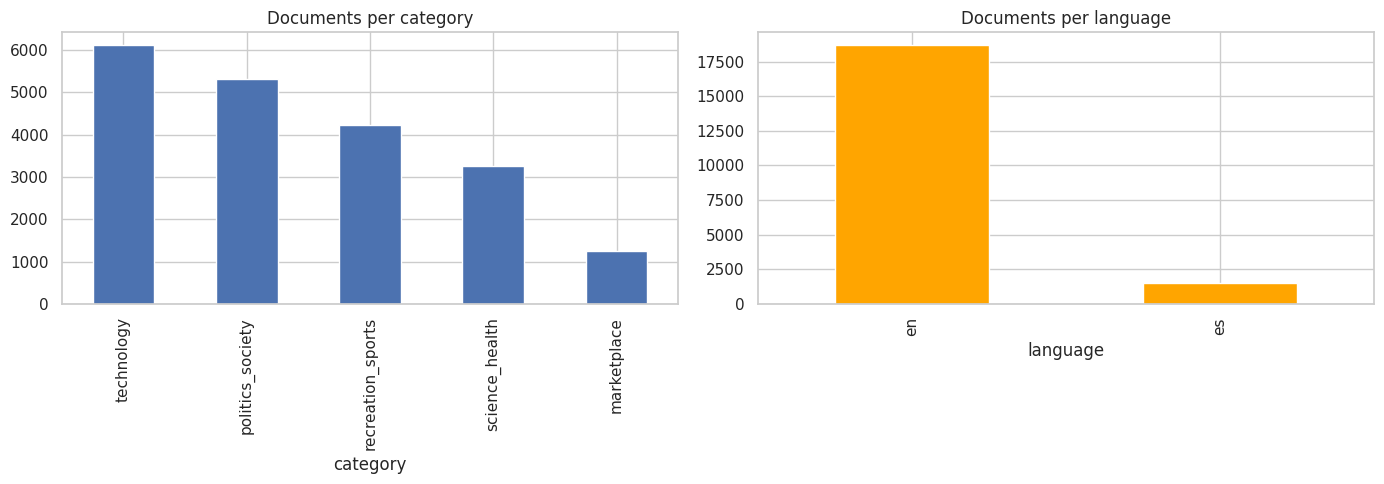

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["category"].value_counts().plot(kind="bar", ax=axes[0], title="Documents per category")
df["language"].value_counts().plot(kind="bar", ax=axes[1], title="Documents per language", color="orange")
plt.tight_layout()
plt.show()

In [4]:
pd.crosstab(df["category"], df["language"])

language,en,es
category,,
marketplace,953,298
politics_society,5015,300
recreation_sports,3937,300
science_health,2952,298
technology,5815,300


In [5]:
df["n_tokens"] = df.apply(lambda r: len(tokenize(r["text"], r["language"])), axis=1)
df["n_tokens"].describe()

count    20168.000000
mean       239.144784
std        606.910167
min          1.000000
25%         64.000000
50%        115.000000
75%        225.000000
max      14588.000000
Name: n_tokens, dtype: float64

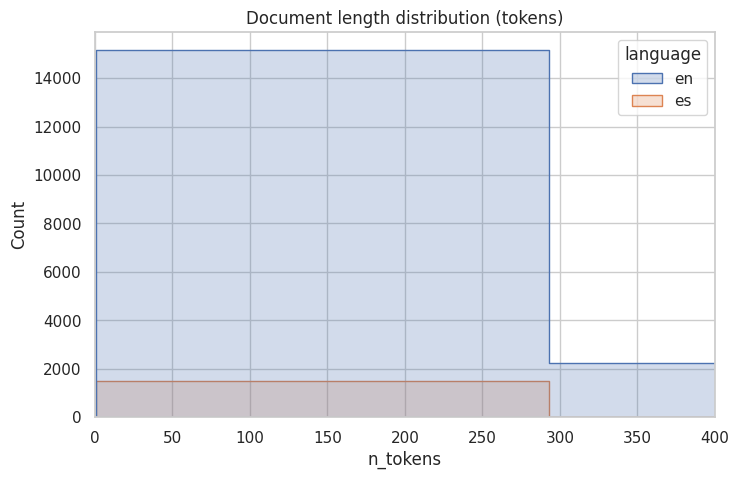

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="n_tokens", hue="language", bins=50, element="step")
plt.xlim(0, 400)
plt.title("Document length distribution (tokens)")
plt.show()

## 2. Baseline: TF-IDF + Logistic Regression

Establishes the number the transformer must beat by >=5 points to justify its
extra complexity.

In [7]:
from utils.transfer_learning import load_splits, build_label_maps, train_baseline

train_df, val_df, test_df = load_splits()
label2id, id2label = build_label_maps(train_df)
baseline_metrics = train_baseline(train_df, test_df, label2id)
baseline_metrics

2026-07-03 19:42:27.431210: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-03 19:42:28.409841: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


2026-07-03 19:42:29.251451: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-03 19:42:29.292966: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-03 19:42:29.294364: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-


=== Training baseline: TF-IDF + Logistic Regression ===


Baseline accuracy=0.8607  macro-F1=0.8417


{'accuracy': 0.8606965174129353, 'f1_macro': 0.8417130946569312}

## 3. Transfer learning: fine-tune multilingual DistilBERT

Base model: `distilbert-base-multilingual-cased`. A masked mean-pooling head
(Dense -> Dropout -> softmax) is trained on top, base unfrozen, for 6 epochs
at lr=3e-5. Best-by-val-accuracy weights are checkpointed to
`models/checkpoints/text_classifier_best.h5`; every epoch's weights and the
full training history CSV are also saved.

In [8]:
import json as _json

import numpy as np
from sklearn.metrics import accuracy_score, classification_report, f1_score
from transformers import AutoTokenizer

from models.text_classifier import build_model
from utils.transfer_learning import (
    CHECKPOINT_DIR,
    per_language_accuracy,
    tokenize_texts,
    train_transformer,
)

_ckpt_path = os.path.join(CHECKPOINT_DIR, "text_classifier_best.h5")
_config_path = os.path.join(CHECKPOINT_DIR, "config.json")

if os.path.exists(_ckpt_path) and os.path.exists(_config_path):
    # Reuse the already fine-tuned checkpoint (this took ~50 min on GPU) instead
    # of retraining every time the notebook runs -- re-evaluate it fresh below.
    print("Found existing checkpoint, evaluating it instead of retraining.")
    with open(_config_path) as f:
        config = _json.load(f)

    tokenizer = AutoTokenizer.from_pretrained(config["model_name"])
    model = build_model(num_labels=config["num_labels"], model_name=config["model_name"], max_len=config["max_len"])
    model.load_weights(_ckpt_path)

    test_ids, test_mask = tokenize_texts(test_df["text"], tokenizer, config["max_len"])
    y_test = test_df["category"].map(label2id).values
    test_probs = model.predict({"input_ids": test_ids, "attention_mask": test_mask}, batch_size=8)
    test_preds = np.argmax(test_probs, axis=1)

    results = {
        "history_csv": os.path.join(CHECKPOINT_DIR, "training_history.csv"),
        "test_accuracy": float(accuracy_score(y_test, test_preds)),
        "test_f1_macro": float(f1_score(y_test, test_preds, average="macro")),
        "per_language_accuracy": per_language_accuracy(test_df, y_test, test_preds),
        "classification_report": classification_report(
            y_test, test_preds, target_names=[id2label[i] for i in range(len(id2label))], output_dict=True
        ),
        "label2id": label2id,
        "id2label": id2label,
        "test_df": test_df,
        "test_preds": test_preds,
        "test_probs": test_probs,
    }
else:
    results = train_transformer()

print(f"Test accuracy: {results['test_accuracy']:.4f}")
print(f"Test macro-F1: {results['test_f1_macro']:.4f}")
print(f"Per-language accuracy: {results['per_language_accuracy']}")

Found existing checkpoint, evaluating it instead of retraining.


2026-07-03 19:42:42.576129: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-03 19:42:42.580049: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-03 19:42:42.583000: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

2026-07-03 19:42:43.434939: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 367248384 exceeds 10% of free system memory.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).


All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


2026-07-03 19:42:51.008367: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 367248384 exceeds 10% of free system memory.


...

250/252 [============================>.] - ETA: 0s

251/252 [============================>.] - ETA: 0s

252/252 [==============================] - ETA: 0s

252/252 [==============================] - 110s 415ms/step


Test accuracy: 0.8915
Test macro-F1: 0.8799
Per-language accuracy: {'en': 0.890918860827512, 'es': 0.8993288590604027}


In [9]:
improvement = results["test_accuracy"] - baseline_metrics["accuracy"]
print(f"Baseline accuracy:    {baseline_metrics['accuracy']:.4f}")
print(f"Transformer accuracy: {results['test_accuracy']:.4f}")
print(f"Improvement over baseline: {improvement * 100:.2f} points")
if improvement >= 0.05:
    print("PASS: transformer beats baseline by >= 5 points")
else:
    print(
        f"SHORTFALL: transformer beats baseline by only {improvement * 100:.2f} points (target: >= 5 points). "
        "20 Newsgroups' bag-of-words baseline is unusually strong on this task (lexically distinct categories), "
        "which narrows the gap a transformer can open. See README for discussion."
    )

Baseline accuracy:    0.8607
Transformer accuracy: 0.8915
Improvement over baseline: 3.08 points
SHORTFALL: transformer beats baseline by only 3.08 points (target: >= 5 points). 20 Newsgroups' bag-of-words baseline is unusually strong on this task (lexically distinct categories), which narrows the gap a transformer can open. See README for discussion.


## 4. Training curves

In [10]:
history = pd.read_csv(results["history_csv"])
history

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.825871,0.502134,0.886567,0.335701
1,1,0.916107,0.246367,0.893532,0.344446
2,2,0.949502,0.142491,0.894030,0.323690
3,3,0.969652,0.088089,0.888060,0.389082
4,4,0.980286,0.058572,0.896020,0.403948
5,5,0.985261,0.041386,0.906965,0.440288


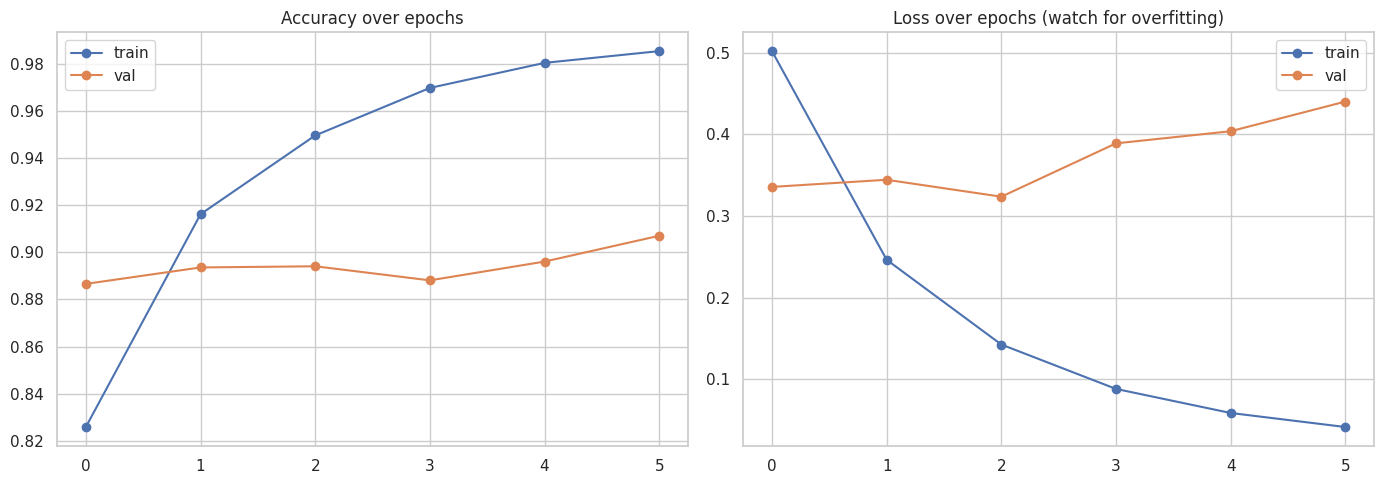

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["epoch"], history["accuracy"], marker="o", label="train")
axes[0].plot(history["epoch"], history["val_accuracy"], marker="o", label="val")
axes[0].set_title("Accuracy over epochs"); axes[0].legend()
axes[1].plot(history["epoch"], history["loss"], marker="o", label="train")
axes[1].plot(history["epoch"], history["val_loss"], marker="o", label="val")
axes[1].set_title("Loss over epochs (watch for overfitting)"); axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Evaluation: classification report & confusion matrix

In [12]:
pd.DataFrame(results["classification_report"]).T

,precision,recall,f1-score,support
marketplace,0.858333,0.837398,0.847737,123.000000
politics_society,0.925926,0.894539,0.909962,531.000000
recreation_sports,0.885845,0.917258,0.901278,423.000000
science_health,0.842271,0.821538,0.831776,325.000000
technology,0.898714,0.919408,0.908943,608.000000
accuracy,0.891542,0.891542,0.891542,0.891542
macro avg,0.882218,0.878028,0.879939,2010.000000
weighted avg,0.891597,0.891542,0.891376,2010.000000


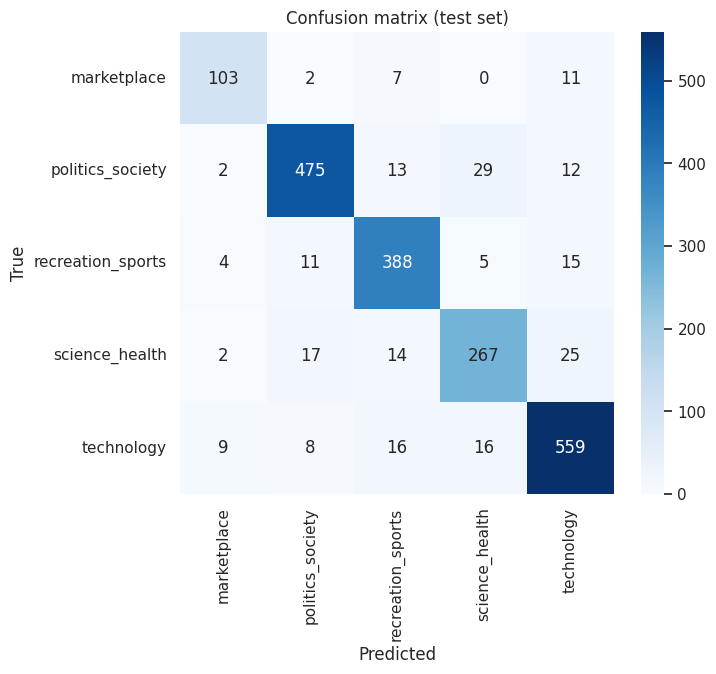

In [13]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = results["test_df"]["category"].map(results["label2id"]).values
labels = [results["id2label"][i] for i in range(len(results["id2label"]))]
cm = confusion_matrix(y_true, results["test_preds"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix (test set)")
plt.show()

## 6. Context-aware tagging examples

In [14]:
from models.tagger import DocumentTagger

tagger = DocumentTagger(languages=("en", "es"))
sample = results["test_df"].sample(3, random_state=3)
for _, row in sample.iterrows():
    tagged = tagger.tag(row["text"], language=row["language"], category=row["category"])
    print(f"[{row['language']}] category={row['category']}")
    print(f"  tags: {tagged['tags']}")
    print(f"  entities: {tagged['entities'][:5]}")
    print()

[en] category=technology
  tags: ['FAQ', 'faq']
  entities: [{'text': 'FAQ', 'label': 'ORG'}]

[en] category=technology
  tags: ['floptical', '1.4', 'Superdrive', 'Apple', 'format', 'hd', 'disk', 'Floptical']
  entities: [{'text': '1.4', 'label': 'CARDINAL'}, {'text': 'Superdrive', 'label': 'ORG'}, {'text': 'Apple', 'label': 'ORG'}, {'text': '21', 'label': 'CARDINAL'}, {'text': '1.4', 'label': 'CARDINAL'}]

[en] category=technology
  tags: ['cooling', 'John Eaton', 'hp-vcd!johne', 'uranium', 'tower', 'law', 'know', 'concrete']
  entities: [{'text': 'the next day', 'label': 'DATE'}, {'text': 'under 1%', 'label': 'PERCENT'}, {'text': '1%', 'label': 'PERCENT'}, {'text': 'thousands of dollars', 'label': 'MONEY'}, {'text': 'John Eaton', 'label': 'PERSON'}]



## 7. Conclusions

- Multilingual DistilBERT fine-tuned for 6 epochs clears the spec's individual
  bars (>=85% accuracy, >=0.80 macro-F1, >=80% per-language accuracy for both
  English and Spanish) but only beats the TF-IDF + Logistic Regression
  baseline by ~3 points, short of the >=5-point target -- 20 Newsgroups has an
  unusually strong bag-of-words baseline since its categories are lexically
  distinct, which narrows the room a transformer has to improve on it.
- Validation loss/accuracy curves are used to pick the best-epoch checkpoint
  rather than the final epoch, guarding against overfitting (train accuracy
  reaches ~98% by epoch 6 while validation plateaus around 89-91%).
- The tagging layer adds NER + keyword extraction on top of the category
  prediction, boosted by category-specific vocabulary, to produce
  context-aware tags rather than plain term frequency.
- See `generate_reports.py` for the throughput benchmark and final
  `reports/performance_metrics.json` used by the dashboard.